# Week 4: 다변량 분석 및 종합 실습 (Multivariate & Comprehensive Analysis)

## 1. 환경 설정
분석에 필요한 라이브러리를 로드하고 데이터셋을 준비합니다.

In [2]:
import pandas as pd
import numpy as np
import random as rd

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic      #mosaic plot!

import scipy.stats as spst

# 시각화 설정
sns.set_theme(style="whitegrid")
!rm ~/.cache/matplotlib -rf
# 2. 한글 설정 적용
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 로드
Carseats 데이터를 로드하여 분석을 준비합니다.

In [3]:
data = pd.read_csv('content/Carseats.csv')
data.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Urban,US
0,9.50,138,73,11,276,120,Bad,42,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,Yes,No


## 3. 다변량 분석: 범주형 -> 범주형
두 범주형 변수 간의 관계를 분석합니다. (교차표 및 카이제곱 검정)

US         No  Yes
ShelveLoc         
Bad        34   62
Good       24   61
Medium     84  135


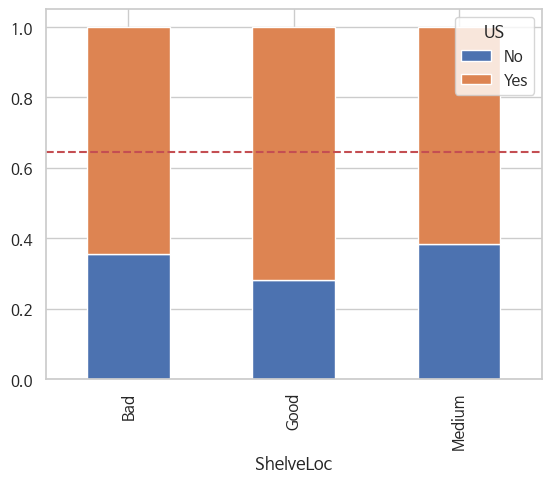

Chi-square statistic: 2.7397
P-value: 0.2541


In [4]:
# 예: ShelveLoc(진열위치)와 US(미국여부)의 관계
temp = pd.crosstab(data['ShelveLoc'], data['US'])
print(temp)

# 시각화 (100% Stacked Bar Chart)
temp_norm = pd.crosstab(data['ShelveLoc'], data['US'], normalize='index')
temp_norm.plot.bar(stacked=True)
plt.axhline(data['US'].value_counts(normalize=True)['Yes'], color='r', linestyle='--')
plt.show()

# 통계 검정 (Chi-square test)
chi2, p, dof, expected = spst.chi2_contingency(temp)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

Sex         female      male
Survived                    
0         0.257962  0.811092
1         0.742038  0.188908


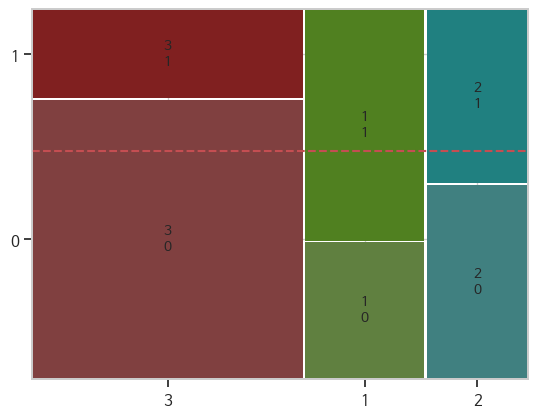

In [5]:
titanic = pd.read_csv('content/titanic_train.csv')

def extract_title(name):
    if 'Mr.' in name:
        return 'Mr'
    elif 'Mrs.' in name:
        return 'Mrs'
    elif 'Miss.' in name:
        return 'Miss'
    elif 'Master' in name:
        return 'Master'
    else:
        return 'Others'
    
titanic['Title'] = titanic['Name'].apply(extract_title)

temp = pd.crosstab(titanic['Survived'], titanic['Sex'], normalize='columns')
print(temp)

mosaic(titanic, ['Pclass', 'Survived'])
plt.axhline(1- titanic['Survived'].mean(), color='r', linestyle='--')
plt.show()

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363
------------------------------


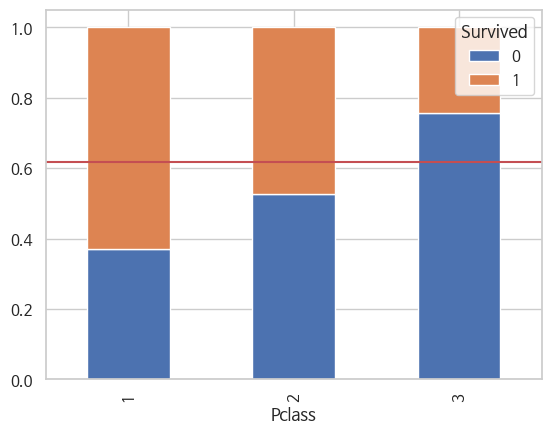

In [6]:
temp = pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize='index')
print(temp)
print('-'*30)

temp.plot.bar(stacked=True)
plt.axhline(1-titanic['Survived'].mean(), color='r')       
plt.show()

카이제곱 통계량: 260.71702016732104
P-value: 1.1973570627755645e-58


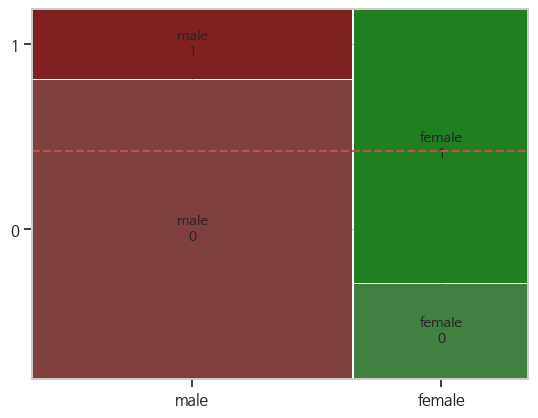

카이제곱 통계량: 26.48914983923762
P-value: 1.769922284120912e-06


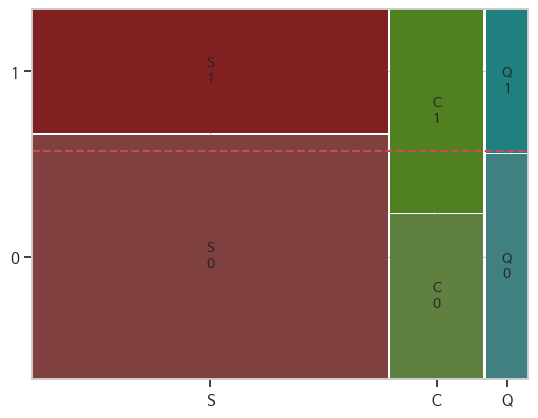

카이제곱 통계량: 283.3115089621979
P-value: 4.305036064730923e-60


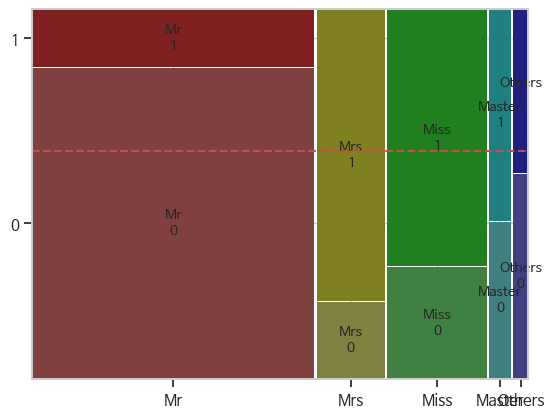

In [7]:
table = pd.crosstab(titanic['Survived'], titanic['Sex'])
result = spst.chi2_contingency(table)
print(f'카이제곱 통계량: {result[0]}')
print(f'P-value: {result[1]}')
mosaic(titanic, ['Sex', 'Survived'])
plt.axhline(1- titanic['Survived'].mean(), color='r', linestyle='--')
plt.show()

table = pd.crosstab(titanic['Survived'], titanic['Embarked'])
result = spst.chi2_contingency(table)
print(f'카이제곱 통계량: {result[0]}')
print(f'P-value: {result[1]}')
mosaic(titanic, ['Embarked', 'Survived'])
plt.axhline(1- titanic['Survived'].mean(), color='r', linestyle='--')
plt.show()

table = pd.crosstab(titanic['Survived'], titanic['Title'])
result = spst.chi2_contingency(table)
print(f'카이제곱 통계량: {result[0]}')
print(f'P-value: {result[1]}')
mosaic(titanic, ['Title', 'Survived'])
plt.axhline(1- titanic['Survived'].mean(), color='r', linestyle='--')
plt.show()

* 카이제곱검정 : 범주형 변수들 사이에 어떤 관계가 있는지, 수치화 하는 방법
- 카이 제곱 통계량
    - 계산 목적: 관측값(실제 데이터)과 기대값(관계가 없다고 가정했을 때의 값)의 차이를 측정하여, 두 범주형 변수 사이에 연관성이 있는지 확인함.
    - 클수록 기대빈도로부터 실제 값에 차이가 크다는 의미.
    - 계산식으로 볼 때, 범주의 수가 늘어날 수록 값은 커지게 되어 있음.
    - 보통, 자유도의 2~3배 보다 크면, 차이가 있다고 본다.

- 범주형 변수의 자유도 : 범주의 수 - 1

- 카이제곱검정에서는
    - x 변수의 자유도 × y 변수의 자유도
    - 예 : Pclass --> Survived
        - Pclass : 범주가 3개, Survived : 2개
        - (3-1) * (2-1) = 2
        - 그러므로, 2의 2 ~ 3배인 4 ~ 6 보다 카이제곱 통계량이 크면, 차이가 있다고 볼수 있음.


In [8]:
table = pd.crosstab(titanic['Survived'], titanic['Sex'])
result = spst.chi2_contingency(table)
print(f'카이제곱 통계량: {result[0]}')
print(f'P-value: {result[1]}')

카이제곱 통계량: 260.71702016732104
P-value: 1.1973570627755645e-58


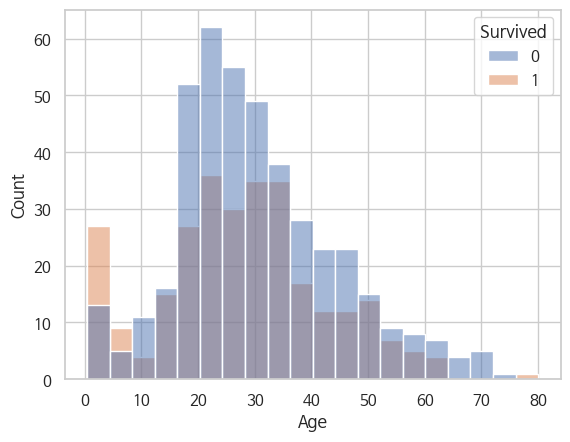

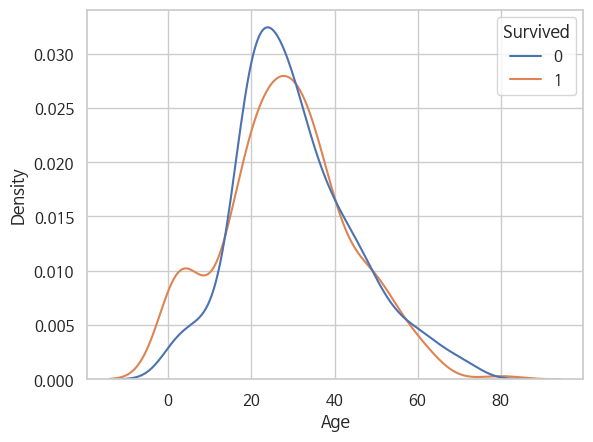

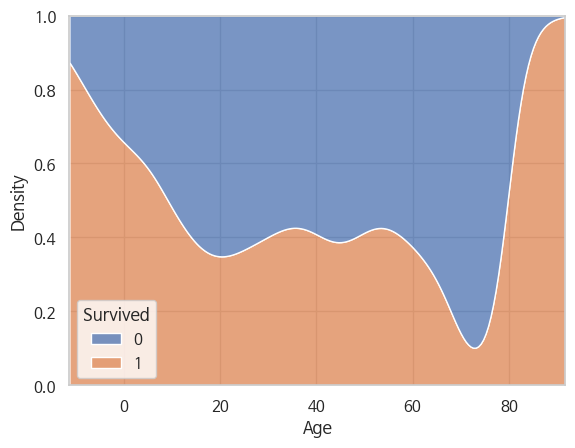

In [9]:
sns.histplot(x='Age', data=titanic, hue='Survived')
plt.show()
sns.kdeplot(x='Age', data=titanic, hue='Survived', common_norm=False , )
plt.show()
sns.kdeplot(x='Age', data=titanic, hue='Survived', multiple='fill', )
plt.show()

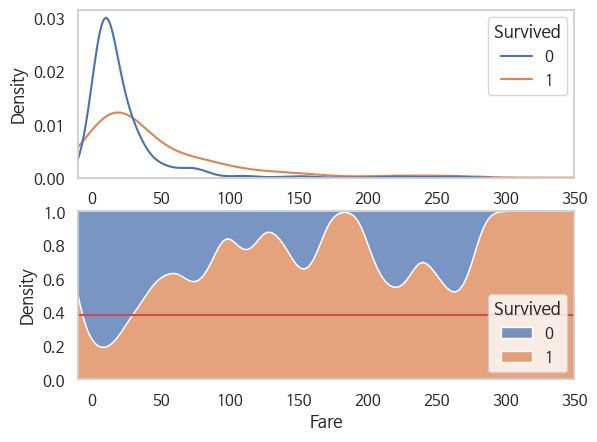

In [10]:
plt.subplot(2,1,1)
sns.kdeplot(x='Fare', data = titanic, hue ='Survived', common_norm=False)
plt.xlim(-10,350)   # 위아래 차트 x값 범위 맞추기
plt.grid()

plt.subplot(2,1,2)
sns.kdeplot(x='Fare', data = titanic, hue ='Survived', multiple = 'fill')
plt.axhline(titanic['Survived'].mean(), color = 'r')
plt.xlim(-10,350)
plt.grid()

plt.show()

- 직원 이직 분석
    - 회사에서 최근 1~2년 사이 이직률이 상승하였다.
    - 여러분은, 직원들이 이직하는데 중요한 요인이 무엇인지 데이터를 기반으로 한 분석을 의뢰 받았다.

In [11]:
attr = pd.read_csv('content/Attrition.csv')

attr.info()

<class 'pandas.DataFrame'>
RangeIndex: 1196 entries, 0 to 1195
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Attrition          1196 non-null   int64
 1   Age                1196 non-null   int64
 2   DistanceFromHome   1196 non-null   int64
 3   EmployeeNumber     1196 non-null   int64
 4   Gender             1196 non-null   str  
 5   JobSatisfaction    1196 non-null   int64
 6   MaritalStatus      1196 non-null   str  
 7   MonthlyIncome      1196 non-null   int64
 8   OverTime           1196 non-null   str  
 9   PercentSalaryHike  1196 non-null   int64
 10  TotalWorkingYears  1196 non-null   int64
dtypes: int64(8), str(3)
memory usage: 119.2 KB


카이제곱 통계량: 2.5537631338119975
P-value: 0.1100318964829815


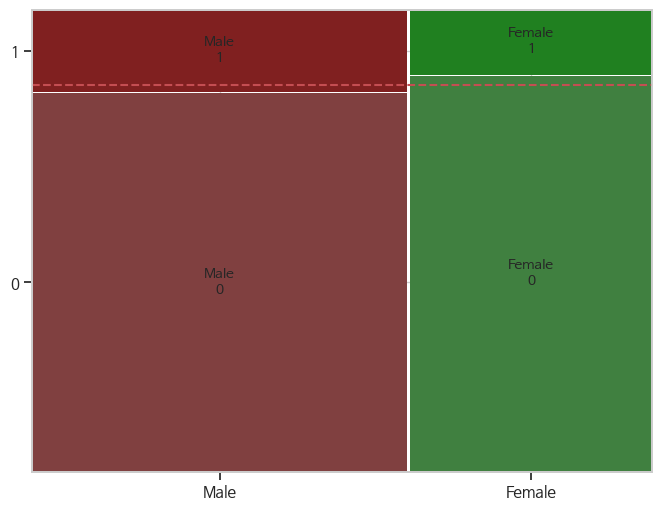

In [15]:
def range_range_stat(feature, target, data):
    table = pd.crosstab(data[feature], data[target])
    result = spst.chi2_contingency(table)
    print(f'카이제곱 통계량: {result[0]}')
    print(f'P-value: {result[1]}')
    mosaic(data, [feature, target])
    plt.axhline(1- data[target].mean(), color='r', linestyle='--')
    plt.show()

feature, target = 'Gender', 'Attrition'
data = attr

range_range_stat(feature, target, data)

- 파악한 것
    - 그래프 상 큰 차이가 없음
    - 수치 결과도 연관이 없다고 비춰짐

카이제곱 통계량: 8.40684948576828
P-value: 0.0383107376547955


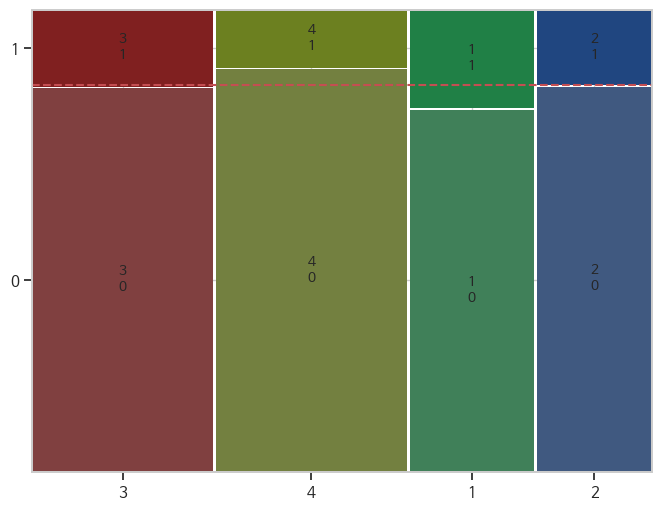

In [14]:
feature, target = 'JobSatisfaction', 'Attrition'

range_range_stat(feature, target, data)

- 파악한 것
    - 만족도 별 이직 비율이 모두 평균 근처에서 머무르나 매우 만족과 매우 불만족이 근소하게 차이가 남
    - 수치도 p-value 1퍼로 관계가 있다고 비춰짐

카이제곱 통계량: 47.82247929575401
P-value: 4.12553775054082e-11


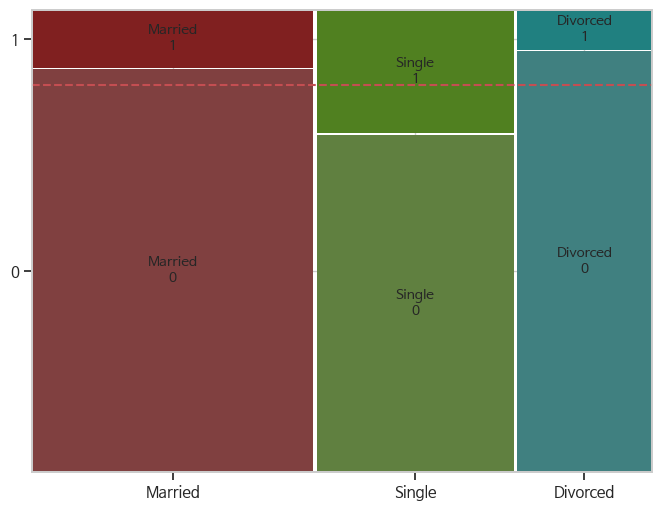

In [16]:
feature = 'MaritalStatus'

range_range_stat(feature, target, data)

- 파악한 것
    - 독신일 수록 이직하는 경향이 보임
    - 반면 기혼, 이혼자는 이직을 하지 않음
    - 수치 역시 연관성이 높다는 결과
    - 독신의 자유로움이 이직을 기회로 잡기 쉬운 듯

카이제곱 통계량: 71.28471646317081
P-value: 3.092218315896121e-17


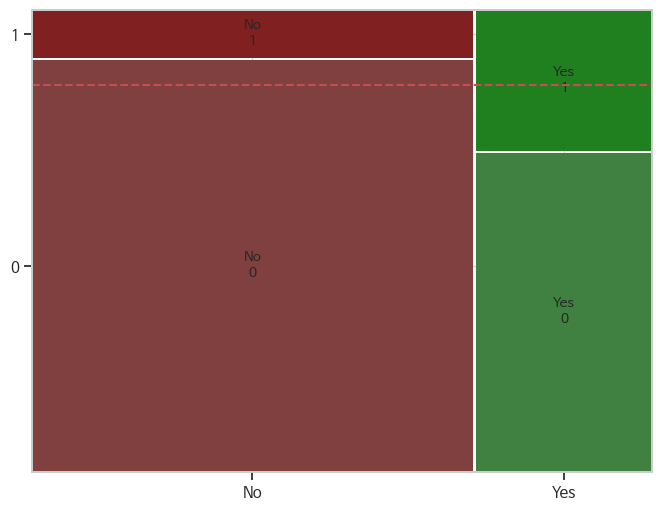

In [17]:
feature = 'OverTime'

range_range_stat(feature, target, data)

- 파악한 것
    - 야근을 할 수록 이직률이 높음
    - 수치 역시 높게 측정
    - 야근을 줄일 수 있는 방법 모색

T-통계량: 5.883996279890771
P-value: 5.195700252508081e-09


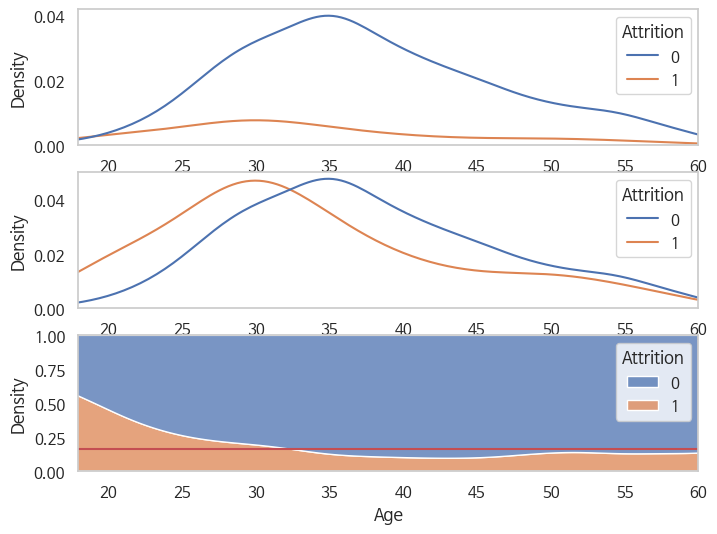

In [22]:
def num_range_stat(feature, target, data):
    group0 = data.loc[data[target] == 0, feature]
    group1 = data.loc[data[target] == 1, feature]
    # ttest_ind(집단1, 집단2)
    result = spst.ttest_ind(group0, group1)
    print(f'T-통계량: {result[0]}')
    print(f'P-value: {result[1]}')

    plt.subplot(3,1,1)
    sns.kdeplot(x=feature, data = data, hue =target, common_norm=True)
    plt.xlim(data[feature].min(),data[feature].max())   # 위아래 차트 x값 범위 맞추기
    plt.grid()

    plt.subplot(3,1,2)
    sns.kdeplot(x=feature, data = data, hue =target, common_norm=False)
    plt.xlim(data[feature].min(),data[feature].max())   # 위아래 차트 x값 범위 맞추기
    plt.grid()

    plt.subplot(3,1,3)
    sns.kdeplot(x=feature, data = data, hue =target, multiple = 'fill')
    plt.axhline(data[target].mean(), color = 'r')
    plt.xlim(data[feature].min(),data[feature].max())
    plt.grid()

    plt.show()

feature = 'Age'

num_range_stat(feature, target, data)

- 파악한 것
    - 나이가 20대, 30대 초일 수록 이직이 잦음
    - 그 이상은 이직이 높지 않음
    - 젊을 수록 기회가 많음

T-통계량: -2.8420809774497613
P-value: 0.00455826828397374


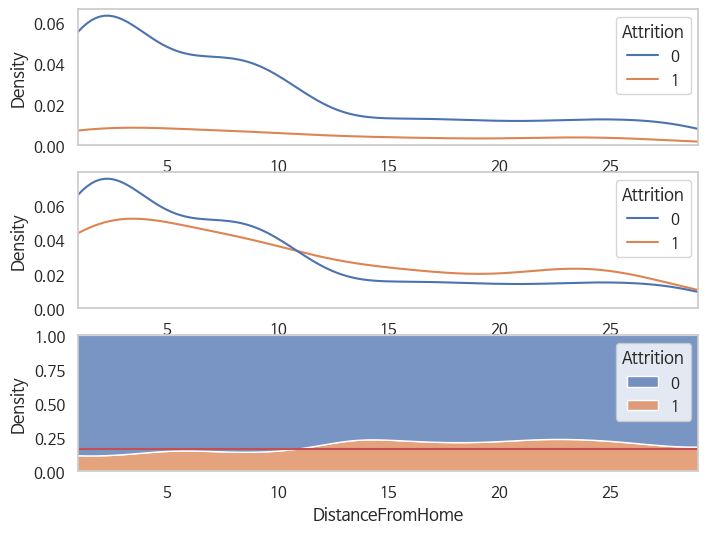

In [23]:
feature = 'DistanceFromHome'

num_range_stat(feature, target, data)

- 파악한 것
    - multiple='fill' 그래프로 봤을 때 거리가 10km 넘어가는 순간 퇴사 확률이 높아짐
    - common_norm=False로 분포를 보면 퇴사 집단이 더 분포가 넓음
    - 원거리 거주자는 퇴사 리스크가 있음

T-통계량: 5.729265979175031
P-value: 1.2757841049555912e-08


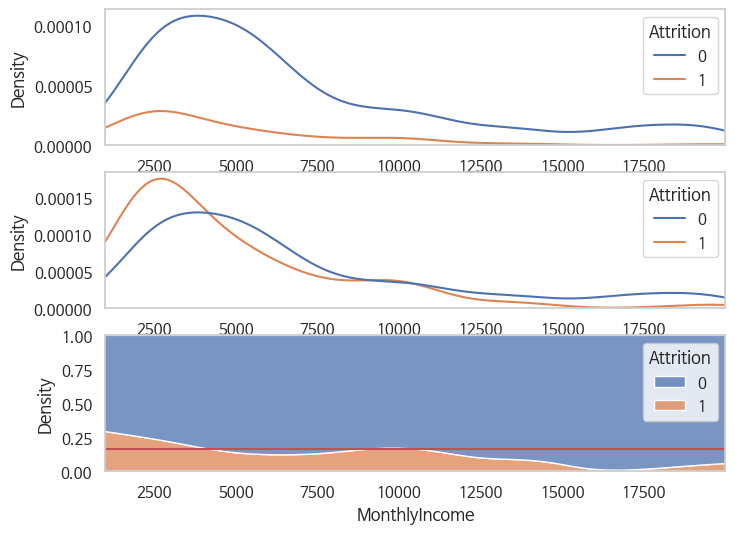

In [24]:
feature = 'MonthlyIncome'

num_range_stat(feature, target, data)

- 파악한 것
    - 대부분의 직원은 7500 아래의 연봉임
    - 퇴사 집단은 연봉 5000미만에 몰려있음
    - 퇴사가 제일 많은 구간은 연봉 4000미만임
    - 저임금 노동자의 처우를 고민해야함

T-통계량: 0.0016418682268953607
P-value: 0.9986902535436575


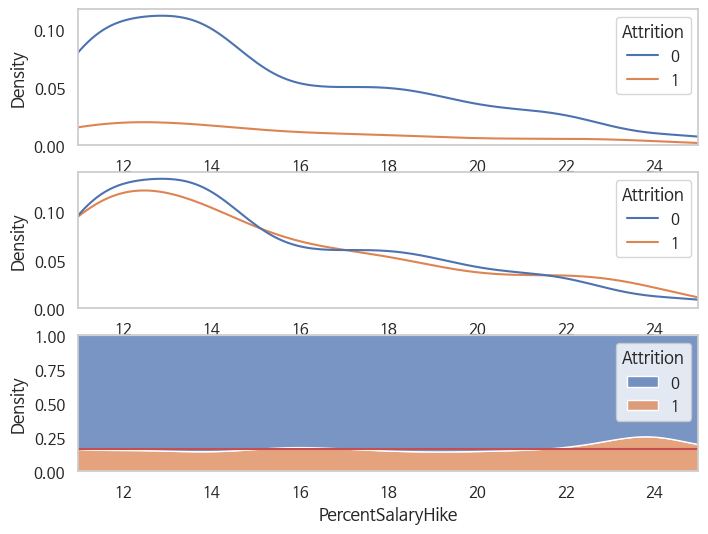

In [25]:
feature = 'PercentSalaryHike'

num_range_stat(feature, target, data)

- 파악한 것
    - 대부분의 직원은 연봉 인상률이 16퍼 이하임
    - 톼사, 근속 집단 모두 고르게 분포되어있음
    - 연봉 인상률이 23퍼가 넘어가면 퇴사하는 특이점이 있지만 표본 부족일 가능성
    - 이직 방지를 위한 연봉 인상은 무의미할 수 있음

T-통계량: 6.401571841692611
P-value: 2.2053117795408476e-10


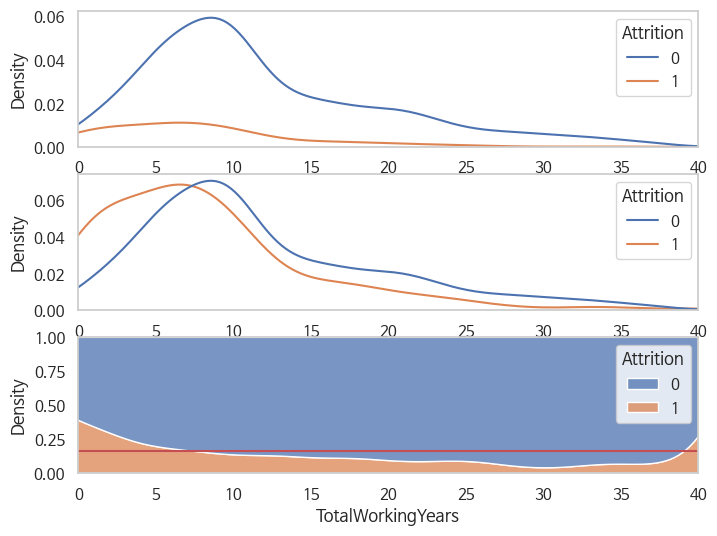

In [26]:
feature = 'TotalWorkingYears'

num_range_stat(feature, target, data)

- 파악한 것
    - 직원의 근속년수는 5~10년 사이에 몰려있음
    - 퇴사 집단은 0~10, 근속집단은 5~12에 퍼져있음
    - 5년 미만 근무자의 퇴사 확률이 높고 40년 차는 정년 퇴직으로 예상
    - mz세대의 참을성 부족으로 예상

In [32]:
target = 'Attrition'


# 분석할 변수 리스트 (총 9개)
cat_features = ['Gender', 'JobSatisfaction', 'MaritalStatus', 'OverTime']
num_features = ['Age', 'DistanceFromHome', 'MonthlyIncome', 'PercentSalaryHike', 'TotalWorkingYears']
results = []
# --- [2. 범주형 분석 수행] ---
for feature in cat_features:
    table = pd.crosstab(data[target], data[feature])
    chi_result = spst.chi2_contingency(table)
    results.append({
        'Feature': feature,
        'Test': 'Chi-square',
        'Statistic': round(chi_result[0], 4),
        'P-value': chi_result[1]
    })
# --- [3. 수치형 분석 수행] ---
for feature in num_features:
    temp = data[[target, feature]].dropna()
    g0 = temp.loc[temp[target] == 0, feature]
    g1 = temp.loc[temp[target] == 1, feature]
    t_result = spst.ttest_ind(g0, g1)
    results.append({
        'Feature': feature,
        'Test': 'T-test',
        'Statistic': round(abs(t_result[0]), 4), # 비교를 위해 절대값 사용
        'P-value': t_result[1]
    })
# --- [4. 순위 산정 및 관계 분류] ---
# P-value가 작을수록 관계가 강하므로 오름차순 정렬
df_final = pd.DataFrame(results).sort_values(by='P-value').reset_index(drop=True)
df_final['Rank'] = df_final.index + 1
# 순위에 따른 강제 분류 (1-3, 4-6, 7-9)
def classify_by_rank(rank):
    if rank <= 3:
        return "강한 관계"
    elif rank <= 6:
        return "중간 관계"
    else:
        return "관계 없음"
df_final['Final_Relation'] = df_final['Rank'].apply(classify_by_rank)
# --- [5. 최종 리포트 출력 (DataFrame 형태)] ---
# 1. 가독성을 위해 컬럼명 변경 및 필요한 컬럼만 선택
df_report = df_final[['Rank', 'Feature', 'Test', 'Statistic', 'P-value', 'Final_Relation']].copy()
df_report.columns = ['순위', '변수명', '검정방식', '통계량', 'P-value', '관계분류']
# 2. 인덱스를 순위로 설정하거나 깔끔하게 제거
df_report.set_index('순위', inplace=True)
# 3. 데이터프레임 출력 (노트북 환경에서는 변수명만 쓰면 예쁘게 나옵니다)
# 소수점 자리수 제한 설정
pd.options.display.float_format = '{:.5f}'.format
df_report

,변수명,검정방식,통계량,P-value,관계분류
순위,,,,,
1,OverTime,Chi-square,71.28470,0.00000,강한 관계
2,MaritalStatus,Chi-square,47.82250,0.00000,강한 관계
3,TotalWorkingYears,T-test,6.40160,0.00000,강한 관계
4,Age,T-test,5.88400,0.00000,중간 관계
5,MonthlyIncome,T-test,5.72930,0.00000,중간 관계
6,DistanceFromHome,T-test,2.84210,0.00456,중간 관계
7,JobSatisfaction,Chi-square,8.40680,0.03831,관계 없음
8,Gender,Chi-square,2.55380,0.11003,관계 없음
9,PercentSalaryHike,T-test,0.00160,0.99869,관계 없음
